In [1]:
# SatEnergy — Notebook 01: Coleta de Dados
# Verificando se todas as bibliotecas estão instaladas corretamente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import geopandas as gpd

print("✅ Todas as bibliotecas carregadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ Todas as bibliotecas carregadas com sucesso!
Pandas: 3.0.3
Numpy: 2.4.6


In [6]:
# Gerando dados simulados realistas para desenvolvimento
# Baseados nos padrões reais de geração solar/eólica do Brasil

import numpy as np
import pandas as pd

np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="h")

df_geracao = pd.DataFrame({
    "data_hora": datas,
    "regiao": np.random.choice(["Nordeste", "Sudeste", "Sul", "Norte", "Centro-Oeste"], len(datas)),
    "geracao_solar_mwh": np.abs(np.random.normal(500, 150, len(datas))),
    "geracao_eolica_mwh": np.abs(np.random.normal(800, 200, len(datas))),
    "irradiancia_wm2": np.abs(np.random.normal(400, 100, len(datas))),
    "velocidade_vento_ms": np.abs(np.random.normal(7, 2, len(datas))),
    "cobertura_nuvens_pct": np.random.uniform(0, 100, len(datas)),
    "temperatura_c": np.random.normal(25, 5, len(datas)),
})

print(f"✅ Dataset criado com {len(df_geracao)} registros!")
print(f"Período: {df_geracao['data_hora'].min()} até {df_geracao['data_hora'].max()}")
print(f"\nColunas: {list(df_geracao.columns)}")
print(f"\nPrimeiros registros:")
print(df_geracao.head())

✅ Dataset criado com 8761 registros!
Período: 2024-01-01 00:00:00 até 2024-12-31 00:00:00

Colunas: ['data_hora', 'regiao', 'geracao_solar_mwh', 'geracao_eolica_mwh', 'irradiancia_wm2', 'velocidade_vento_ms', 'cobertura_nuvens_pct', 'temperatura_c']

Primeiros registros:
            data_hora        regiao  geracao_solar_mwh  geracao_eolica_mwh  \
0 2024-01-01 00:00:00         Norte         524.810549          981.644505   
1 2024-01-01 01:00:00  Centro-Oeste         292.697365          866.789010   
2 2024-01-01 02:00:00           Sul         427.457429          724.018407   
3 2024-01-01 03:00:00  Centro-Oeste         626.267116          911.075931   
4 2024-01-01 04:00:00  Centro-Oeste         342.316996          972.017014   

   irradiancia_wm2  velocidade_vento_ms  cobertura_nuvens_pct  temperatura_c  
0       353.656709             4.850173             94.953864      23.358968  
1       267.772852            10.099928             94.809823      26.508720  
2       276.952394    

✅ Dados salvos em data/processed/geracao_simulada.csv


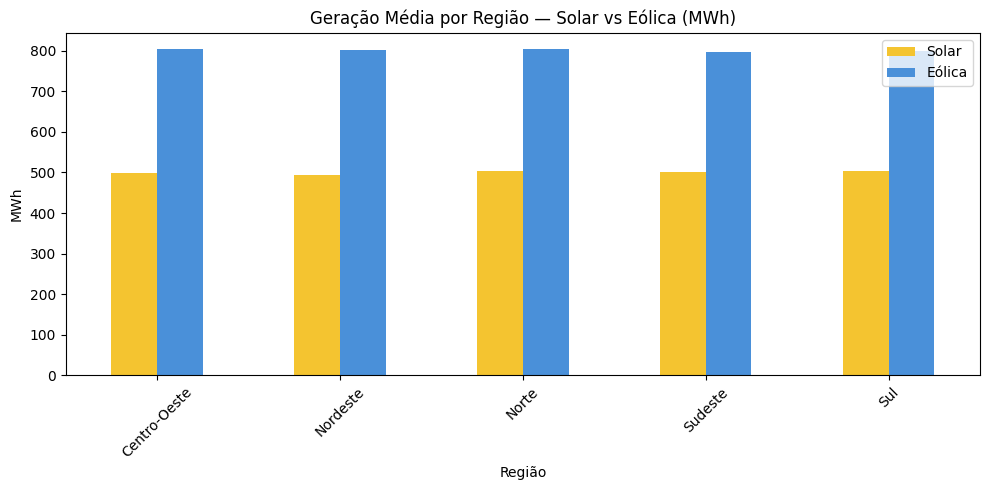

✅ Gráfico salvo!


In [7]:
# Salvando os dados na pasta processed
df_geracao.to_csv("../data/processed/geracao_simulada.csv", index=False)
print("✅ Dados salvos em data/processed/geracao_simulada.csv")

# Primeiro gráfico — geração solar vs eólica por região
import matplotlib.pyplot as plt

df_media = df_geracao.groupby("regiao")[["geracao_solar_mwh", "geracao_eolica_mwh"]].mean()

df_media.plot(kind="bar", figsize=(10, 5), color=["#f4c430", "#4a90d9"])
plt.title("Geração Média por Região — Solar vs Eólica (MWh)")
plt.xlabel("Região")
plt.ylabel("MWh")
plt.xticks(rotation=45)
plt.legend(["Solar", "Eólica"])
plt.tight_layout()
plt.savefig("../data/processed/grafico_geracao_regiao.png")
plt.show()
print("✅ Gráfico salvo!")

In [9]:
# Carregando dados reais do ONS — Fator de Capacidade Eólica e Solar
import glob

# Encontra o arquivo CSV na pasta raw
arquivos = glob.glob("../data/raw/*.csv")
print(f"Arquivos encontrados: {arquivos}")

df_ons = pd.read_csv(arquivos[0], sep=";", encoding="utf-8")
print(f"\n✅ {len(df_ons)} registros carregados!")
print(f"Colunas: {list(df_ons.columns)}")
print(df_ons.head())

Arquivos encontrados: ['../data/raw\\FATOR_CAPACIDADE-2_2026_04.csv']

✅ 166320 registros carregados!
Colunas: ['id_subsistema', 'nom_subsistema', 'id_estado', 'nom_estado', 'cod_pontoconexao', 'nom_pontoconexao', 'nom_localizacao', 'val_latitudesecoletora', 'val_longitudesecoletora', 'val_latitudepontoconexao', 'val_longitudepontoconexao', 'nom_modalidadeoperacao', 'nom_tipousina', 'nom_usina_conjunto', 'id_ons', 'ceg', 'din_instante', 'val_geracaoprogramada', 'val_geracaoverificada', 'val_capacidadeinstalada', 'val_fatorcapacidade']
  id_subsistema nom_subsistema id_estado nom_estado cod_pontoconexao  \
0             N          Norte        MA   MARANHAO      MAMR--500-A   
1            NE       Nordeste        BA      BAHIA      BAIGD-230-B   
2            NE       Nordeste        BA      BAHIA        BAUSB-500   
3            NE       Nordeste        BA      BAHIA      BAMPD-230-A   
4            NE       Nordeste        BA      BAHIA      BAOUR-500-A   

             nom_pontocone

In [11]:
# Análise dos dados reais do ONS
# Filtrando apenas usinas solares e eólicas

df_solar = df_ons[df_ons["nom_tipousina"] == "UFV"]   # Usinas Fotovoltaicas
df_eolica = df_ons[df_ons["nom_tipousina"] == "EOL"]  # Usinas Eólicas

print(f"Usinas solares: {len(df_solar)} registros")
print(f"Usinas eólicas: {len(df_eolica)} registros")

# Fator de capacidade médio por subsistema
print("\n--- Fator de Capacidade Médio por Subsistema ---")
print(df_ons.groupby(["nom_subsistema", "nom_tipousina"])["val_fatorcapacidade"].mean().round(3))

Usinas solares: 0 registros
Usinas eólicas: 0 registros

--- Fator de Capacidade Médio por Subsistema ---
nom_subsistema        nom_tipousina
Nordeste              Eólica           0.263
                      Solar            0.182
Norte                 Eólica           0.121
Sudeste/Centro-Oeste  Solar            0.203
Sul                   Eólica           0.272
Name: val_fatorcapacidade, dtype: float64


✅ Usinas solares: 56160 registros
✅ Usinas eólicas: 110160 registros


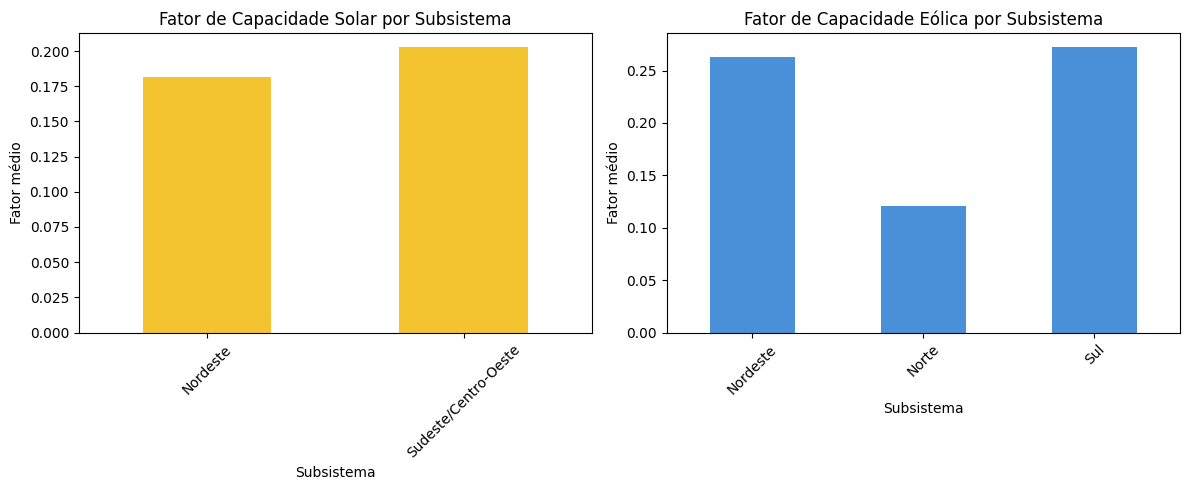

✅ Gráfico salvo com dados reais do ONS!


In [12]:
# Corrigindo os filtros com os nomes corretos
df_solar = df_ons[df_ons["nom_tipousina"] == "Solar"]
df_eolica = df_ons[df_ons["nom_tipousina"] == "Eólica"]

print(f"✅ Usinas solares: {len(df_solar)} registros")
print(f"✅ Usinas eólicas: {len(df_eolica)} registros")

# Gráfico — Fator de capacidade médio por subsistema
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Solar
df_solar.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[0], color="#f4c430"
)
axes[0].set_title("Fator de Capacidade Solar por Subsistema")
axes[0].set_xlabel("Subsistema")
axes[0].set_ylabel("Fator médio")
axes[0].tick_params(axis="x", rotation=45)

# Eólica
df_eolica.groupby("nom_subsistema")["val_fatorcapacidade"].mean().plot(
    kind="bar", ax=axes[1], color="#4a90d9"
)
axes[1].set_title("Fator de Capacidade Eólica por Subsistema")
axes[1].set_xlabel("Subsistema")
axes[1].set_ylabel("Fator médio")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../data/processed/grafico_fator_capacidade_real.png")
plt.show()
print("✅ Gráfico salvo com dados reais do ONS!")

In [13]:
# Testando API do BDQueimadas - INPE
import requests
import warnings
warnings.filterwarnings("ignore")  # ignora warning de SSL

# URL correta do BDQueimadas
url = "http://terrabrasilis.dpi.inpe.br/queimadas/bdqueimadas/api/focos"

params = {
    "dataInicial": "2024-01-01 00:00:00",
    "dataFinal": "2024-01-31 23:59:59",
    "pais": "Brasil",
    "formato": "json"
}

response = requests.get(url, params=params, verify=False, timeout=30)
print(f"Status: {response.status_code}")
print(f"Resposta: {response.text[:500]}")

Status: 404
Resposta: <!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Error</title>
</head>
<body>
<pre>Cannot GET /api/focos</pre>
</body>
</html>



In [18]:
# INPE Dataserver — Focos de calor em tempo quase-real
# Atualizado a cada 10 minutos, sem necessidade de login!

url_base = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/"

r = requests.get(url_base, verify=False, timeout=15)
print(f"Status: {r.status_code}")
print(r.text[:1000])

Status: 200
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<html>
 <head>
  <title>Index of /queimadas/queimadas/focos/csv/10min</title>
  <link rel="stylesheet" href="/includes/css/custom.css" type="text/css">
 </head>
 <body><div class='container'><link rel='icon' type='image/x-icon' href='/favicon.ico'><link rel='stylesheet' href='/includes/css/custom.css'><script src='/includes/js/custom.js'></script><header class='top-header'><h1>Sistema de Transferência de Dados</h1><img src='/includes/img/logo-coids.png' class='logo-coids' alt='Logo COIDS'></header><input type='text' id='filtro' placeholder='🔍 Buscar' />
  
  <table id="indexlist">
   <tr class="indexhead"><th class="indexcolicon"><img src="/icons/blank.gif" alt="[ICO]"></th><th class="indexcolname"><a href="?C=N;O=D">Name</a></th><th class="indexcollastmod"><a href="?C=M;O=A">Last modified</a></th><th class="indexcolsize"><a href="?C=S;O=A">Size</a></th><th class="indexcoldesc"><a href="?C=D;O=A">Description</a></th></

In [19]:
# Extraindo os arquivos CSV disponíveis no diretório
arquivos_csv = re.findall(r'href="(focos_[^"]+\.csv)"', r.text)
print(f"Arquivos disponíveis:")
for a in arquivos_csv:
    print(f"  - {a}")

Arquivos disponíveis:
  - focos_10min_20260524_0000.csv
  - focos_10min_20260524_0010.csv
  - focos_10min_20260524_0020.csv
  - focos_10min_20260524_0030.csv
  - focos_10min_20260524_0040.csv
  - focos_10min_20260524_0050.csv
  - focos_10min_20260524_0100.csv
  - focos_10min_20260524_0110.csv
  - focos_10min_20260524_0120.csv
  - focos_10min_20260524_0130.csv
  - focos_10min_20260524_0140.csv
  - focos_10min_20260524_0150.csv
  - focos_10min_20260524_0200.csv
  - focos_10min_20260524_0210.csv
  - focos_10min_20260524_0220.csv
  - focos_10min_20260524_0230.csv
  - focos_10min_20260524_0240.csv
  - focos_10min_20260524_0250.csv
  - focos_10min_20260524_0300.csv
  - focos_10min_20260524_0310.csv
  - focos_10min_20260524_0320.csv
  - focos_10min_20260524_0330.csv
  - focos_10min_20260524_0340.csv
  - focos_10min_20260524_0350.csv
  - focos_10min_20260524_0400.csv
  - focos_10min_20260524_0410.csv
  - focos_10min_20260524_0420.csv
  - focos_10min_20260524_0430.csv
  - focos_10min_20260524_0

In [21]:
# Baixando os últimos 6 arquivos (1 hora de dados) e juntando
print("Baixando última hora de dados...")

dfs = []
for arquivo in arquivos_csv[-6:]:
    url_arquivo = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/10min/{arquivo}"
    r_csv = requests.get(url_arquivo, verify=False, timeout=15)
    df_temp = pd.read_csv(StringIO(r_csv.text))
    if len(df_temp) > 0:
        dfs.append(df_temp)
        print(f"  ✅ {arquivo} — {len(df_temp)} focos")
    else:
        print(f"  ⬜ {arquivo} — sem focos")

if dfs:
    df_focos = pd.concat(dfs, ignore_index=True)
    print(f"\n✅ Total: {len(df_focos)} focos carregados!")
    print(df_focos.head())
else:
    print("\n⬜ Sem focos na última hora — normal para este horário!")
    print("Vamos buscar dados do dia inteiro...")

Baixando última hora de dados...
  ✅ focos_10min_20260527_1810.csv — 10 focos
  ✅ focos_10min_20260527_1820.csv — 20 focos
  ✅ focos_10min_20260527_1830.csv — 47 focos
  ✅ focos_10min_20260527_1840.csv — 24 focos
  ✅ focos_10min_20260527_1850.csv — 26 focos
  ⬜ focos_10min_20260527_1900.csv — sem focos

✅ Total: 127 focos carregados!
       lat      lon satelite                 data
0   4.1106 -74.9729  GOES-19  2026-05-27 17:40:00
1   4.0560 -74.9549  GOES-19  2026-05-27 17:40:00
2   4.0378 -74.9729  GOES-19  2026-05-27 17:40:00
3   4.0196 -74.9910  GOES-19  2026-05-27 17:40:00
4 -12.9761 -64.8047  GOES-19  2026-05-27 17:40:00


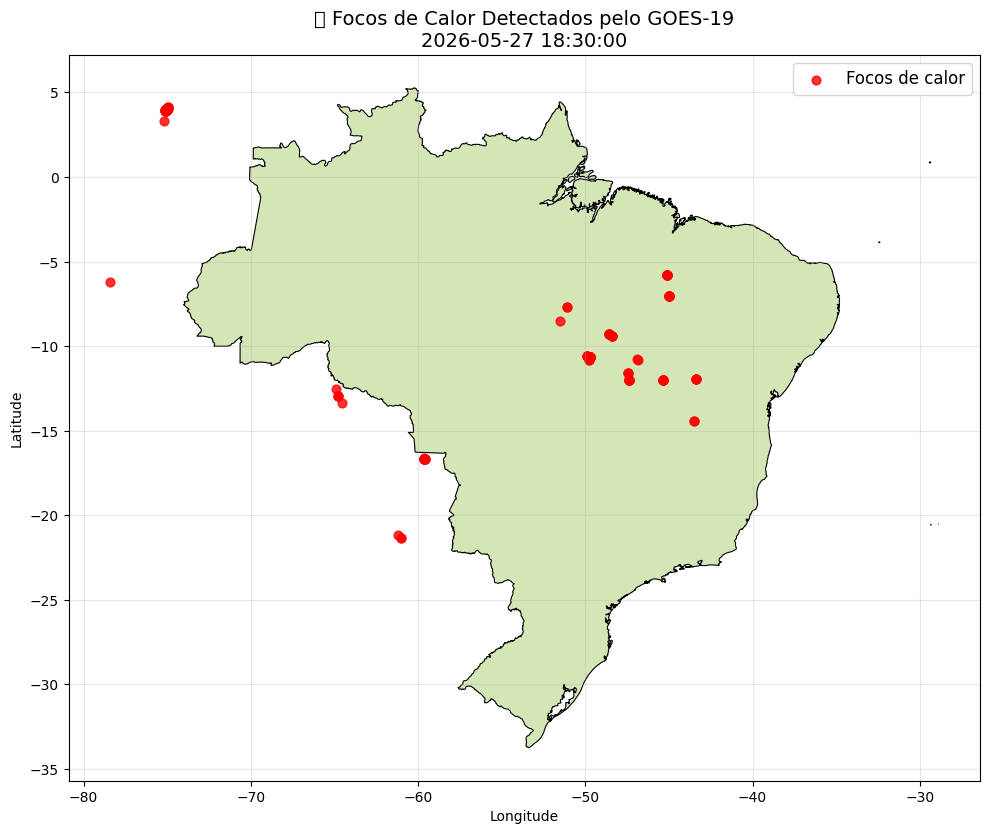

✅ Mapa salvo!


In [26]:
# Mapa melhorado com contorno do Brasil
import geopandas as gpd
from shapely.geometry import Point

# Baixando shapefile do Brasil direto da internet
url_brasil = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
mundo = gpd.read_file(url_brasil)
brasil = mundo[mundo["name"] == "Brazil"]

# Convertendo focos para GeoDataFrame
geometry = [Point(xy) for xy in zip(df_focos["lon"], df_focos["lat"])]
gdf_focos = gpd.GeoDataFrame(df_focos, geometry=geometry, crs="EPSG:4326")

# Plotando
fig, ax = plt.subplots(figsize=(10, 12))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)
gdf_focos.plot(ax=ax, color="red", markersize=40, alpha=0.8, label="Focos de calor")

ax.set_title(f"🔥 Focos de Calor Detectados pelo GOES-19\n{df_focos['data'].max()}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_focos_calor.png", dpi=150)
plt.show()
print("✅ Mapa salvo!")





Total de focos: 127
Focos dentro do Brasil: 72


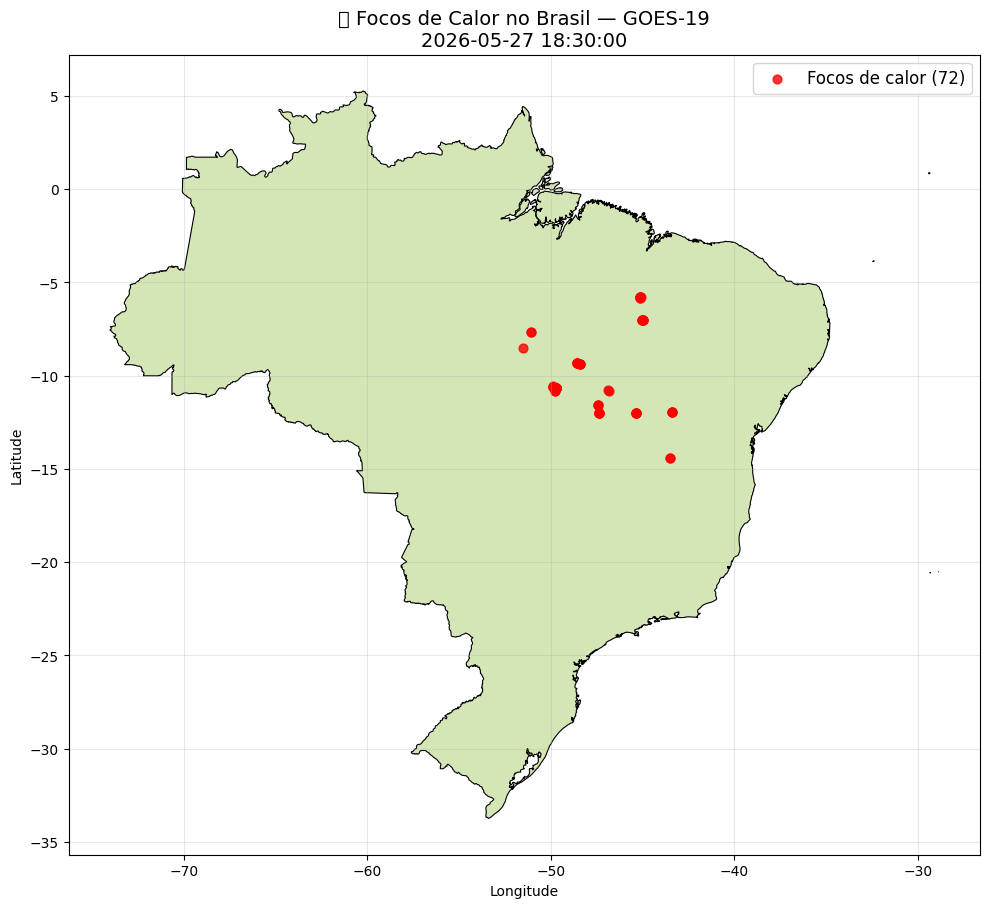

✅ Mapa salvo!


In [27]:
# Filtrando apenas focos dentro do Brasil
from shapely.ops import unary_union

brasil_shape = unary_union(brasil.geometry)
gdf_focos["dentro_brasil"] = gdf_focos.geometry.within(brasil_shape)
df_focos_brasil = gdf_focos[gdf_focos["dentro_brasil"]]

print(f"Total de focos: {len(gdf_focos)}")
print(f"Focos dentro do Brasil: {len(df_focos_brasil)}")

# Plotando apenas focos do Brasil
fig, ax = plt.subplots(figsize=(10, 12))
brasil.plot(ax=ax, color="#d4e6b5", edgecolor="black", linewidth=0.8)
df_focos_brasil.plot(ax=ax, color="red", markersize=40, alpha=0.8, label=f"Focos de calor ({len(df_focos_brasil)})")

ax.set_title(f"🔥 Focos de Calor no Brasil — GOES-19\n{df_focos['data'].max()}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/mapa_focos_calor.png", dpi=150)
plt.show()
print("✅ Mapa salvo!")